# Notebook 20 – Mini Assessment






# Part 1 – Concept Questions

### Q1. What is Machine Learning?

**Answer:** Machine Learning is a way of writing software that **learns patterns from data**, instead of being explicitly programmed with fixed rules. A model is trained on examples and then makes predictions on new, unseen data.

### Q2. Supervised vs Unsupervised Learning?

**Answer:**
* **Supervised learning:** the training data has known **correct answers (labels)**. The model learns to map inputs to those answers (e.g. predicting churn from customer behaviour).
* **Unsupervised learning:** the data has **no labels**. The model finds structure on its own, such as grouping similar customers together (clustering).

### Q3. Classification vs Regression?

**Answer:** Both are supervised learning, but the target is different.
* **Classification** predicts a **category** (e.g. churned / not churned).
* **Regression** predicts a **number** (e.g. an invoice amount in £).

### Q4. What is a feature?

**Answer:** A **feature** (or input variable) is a piece of information used to make a prediction — a column of the dataset given to the model, such as `n_items` or `recency_days`.

### Q5. What is a target?

**Answer:** The **target** (or label) is the value the model is trying to predict — for example `churned` (classification) or `amount` (regression). It is not shown to the model at prediction time.

### Q6. Why split data into train and test?

**Answer:** To check how the model performs on data it has **never seen**. A model can score very well on the data it was trained on simply by memorising it; the test score is a much more honest estimate of real-world performance (Notebook 15).

### Q7. What is overfitting?

**Answer:** The model becomes **too complex** and starts learning the noise in the training data, not just the real pattern. Symptom: **very low training error, but much higher error on new data** (Notebook 15).

### Q8. What is underfitting?

**Answer:** The model is **too simple** to capture the real pattern. Symptom: **high error on both the training data and new data** (Notebook 15).

### Q9. Explain the Bias–Variance Tradeoff.

**Answer:**
* **Bias** = error from a model that is too simple (consistently wrong in the same way) → underfitting.
* **Variance** = error from a model that is too sensitive to the exact training data (its predictions swing a lot if the data changes) → overfitting.
* Making a model more complex **lowers bias but raises variance**. The best model finds the balance point where the *total* error is smallest.

### Q10. Explain Linear Regression.

**Answer:** Linear Regression predicts a **number** as a weighted sum of the features: `ŷ = b₀ + b₁x₁ + b₂x₂ + …`. It finds the weights that make the predicted values as close as possible to the actual values (usually by minimising MSE).

### Q11. Explain Logistic Regression.

**Answer:** Logistic Regression predicts the **probability of a class** (e.g. churn). It takes the same weighted sum as Linear Regression, then squeezes it into the range 0–1 with the **sigmoid function**. A threshold (usually 0.5) turns the probability into a yes/no prediction.

### Q12. Why is Logistic Regression used for classification, not Linear Regression?

**Answer:** Linear Regression can output any number (e.g. −5 or 200), which makes no sense as a probability. Logistic Regression's sigmoid function keeps the output **between 0 and 1**, so it can be read directly as "probability of the positive class", and a clear threshold can be applied.

### Q13. Explain Decision Trees.

**Answer:** A Decision Tree makes predictions with a **flow-chart of yes/no questions** about the features (e.g. "is `recency_days` > 90?"). It keeps splitting the data into purer and purer groups until it reaches a decision at the leaves. It is easy to read but can overfit if left to grow too deep (Notebook 15).

### Q14. Gini Impurity vs Entropy?

**Answer:** Both measure **how mixed the classes are in a group**, and a Decision Tree picks splits that reduce this impurity the most.
* **Gini impurity:** `1 − Σ pᵢ²` — faster to compute, the default in scikit-learn.
* **Entropy:** `−Σ pᵢ log₂(pᵢ)` — from information theory, slightly more expensive to compute.
In practice they usually produce very similar trees.

### Q15. Decision Tree vs Random Forest?

**Answer:** A **Decision Tree** is a single flow-chart — simple and readable, but prone to overfitting. A **Random Forest** trains **many** decision trees on different random samples of the data and features, then **averages their votes**. This reduces variance and usually gives a more accurate, more stable model, at the cost of being harder to interpret (Notebook 18).

### Q16. Explain K-Nearest Neighbours (KNN).

**Answer:** KNN predicts a new point by looking at its **k most similar points** ("neighbours") in the training data, based on distance. For classification it takes a **majority vote** among the neighbours; for regression it takes their **average**. It does no real "training" — it just stores the data and compares at prediction time.

### Q17. Why does KNN require feature scaling?

**Answer:** KNN decides who is "near" using distance (e.g. Euclidean distance). If one feature has a much larger scale than another (e.g. `monetary` in the thousands vs `frequency` in single digits), it will **dominate the distance calculation** and the smaller-scale feature will barely matter. Scaling (e.g. `StandardScaler`) puts every feature on a comparable scale first.

### Q18. Explain SVM (Support Vector Machine).

**Answer:** SVM finds the **boundary that separates the classes with the widest possible margin** — the largest gap between the boundary and the nearest points of each class (the "support vectors"). With the **kernel trick** (e.g. an RBF kernel) it can also draw **curved** boundaries for data that isn't separable with a straight line.

### Q19. Explain K-Means.

**Answer:** K-Means is an **unsupervised clustering** algorithm. You choose a number of groups, **k**. It then: (1) places k random cluster centres, (2) assigns every point to its nearest centre, (3) moves each centre to the average of its assigned points, and (4) repeats steps 2–3 until the assignments stop changing.

### Q20. Accuracy vs Precision vs Recall?

**Answer:** (Notebook 14)
* **Accuracy** = share of **all** predictions that were correct.
* **Precision** = of everything predicted **positive**, how much really was positive (trust in a positive prediction).
* **Recall** = of everything that really **is** positive, how much was found (coverage of real positives).
Accuracy alone can be misleading on imbalanced data; precision and recall reveal the type of mistake being made.

### Q21. What is the F1 Score?

**Answer:** The **harmonic mean of precision and recall**: `F1 = 2 × (Precision × Recall) / (Precision + Recall)`. It is high only when **both** precision and recall are high, so it is a good single-number summary for imbalanced classification (Notebook 14).

### Q22. What is Cross Validation, and how would you select the best model?

**Answer:** Cross validation splits the data into several **folds**, trains on some folds and validates on the remaining fold, repeats this so every fold is used for validation once, and **averages the scores** (Notebook 16). This gives a more reliable estimate than one single train/validation split.

**To select the best model** (Notebook 18): compare several algorithms using cross-validated scores, check the **gap between training and validation score** (a big gap means overfitting), consider **simplicity, speed, and stability**, and **never choose using the test set** — the test set is only for a final, honest check. The model with the single highest accuracy is not automatically the best choice.


# Part 2 – Coding Exercises

We use a small **customer table** built from `data.csv`: for each customer, their purchase `frequency`, `monetary` (total spend, £) and `recency_days` (days since last purchase) before 1 Sep 2011, and whether they **churned** (made no purchase afterwards). This is the same idea as Notebook 17.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
df = pd.read_csv("data.csv", encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
d = df.dropna(subset=["CustomerID"]).drop_duplicates().copy(); d["CustomerID"] = d.CustomerID.astype(int)
sales = d[~d.InvoiceNo.str.startswith("C") & (d.Quantity > 0) & (d.UnitPrice > 0)].copy()
sales["Amount"] = sales.Quantity * sales.UnitPrice
cutoff = pd.Timestamp("2011-09-01")
past, future = sales[sales.InvoiceDate < cutoff], sales[sales.InvoiceDate >= cutoff]
g = past.groupby("CustomerID")
customers = pd.DataFrame({"frequency": g.InvoiceNo.nunique(), "monetary": g.Amount.sum(),
                          "recency_days": (cutoff - g.InvoiceDate.max()).dt.days})
customers["churned"] = (~customers.index.isin(future.CustomerID.unique())).astype(int)

X = customers[["frequency", "monetary", "recency_days"]]
y = customers["churned"]
print(f"Customers: {len(customers)} | Churned: {y.mean():.1%}")
customers.head()

Customers: 3317 | Churned: 41.2%


,frequency,monetary,recency_days,churned
CustomerID,,,,
12346,1,77183.60,225,1
12347,5,2790.86,29,0
12348,3,1487.24,148,0
12350,1,334.40,210,1
12352,5,1561.81,162,0


### Exercise 1 — Train/test split
**Task:** split `X` and `y` into 80% training and 20% test data, keeping the churn rate equal in both (stratified). Use `random_state=42`.

**Solution:**

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", len(X_train), "| Test:", len(X_test))
print("Churn rate -> train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: 2653 | Test: 664
Churn rate -> train: 0.412 | test: 0.411


### Exercise 2 — Train a Logistic Regression model
**Task:** train a `LogisticRegression` on the training data and predict on the test data.

**Solution:**

In [3]:
log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [0 0 0 0 0 1 1 0 1 1]


### Exercise 3 — Evaluate with Accuracy, Precision, Recall and F1
**Task:** compute all four metrics for the Logistic Regression predictions from Exercise 2.

**Solution:**

In [4]:
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1 Score: ", round(f1_score(y_test, y_pred), 3))

Accuracy:  0.654
Precision: 0.585
Recall:    0.542
F1 Score:  0.563


### Exercise 4 — Why KNN needs scaling
**Task:** train a `KNeighborsClassifier` on the **raw** (unscaled) training data, then again on data scaled with `StandardScaler`. Compare test accuracy.

**Solution:**

In [5]:
knn_raw = KNeighborsClassifier().fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))
scaler = StandardScaler().fit(X_train)
knn_scaled = KNeighborsClassifier().fit(scaler.transform(X_train), y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(scaler.transform(X_test)))
print(f"KNN accuracy without scaling: {acc_raw:.3f}")
print(f"KNN accuracy with scaling:    {acc_scaled:.3f}")

KNN accuracy without scaling: 0.639
KNN accuracy with scaling:    0.655


**Why this happens:** `monetary` (£s, often in the thousands) is on a much bigger scale than `frequency` (a handful of orders). Without scaling, distance is calculated almost entirely from `monetary`, so KNN barely "sees" the other features — exactly the problem described in Question 17.

### Exercise 5 — Gini vs Entropy
**Task:** train two decision trees (`max_depth=4`) — one with `criterion="gini"`, one with `criterion="entropy"` — and compare their test accuracy.

**Solution:**

In [6]:
for criterion in ["gini", "entropy"]:
    tree = DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=42).fit(X_train, y_train)
    acc = accuracy_score(y_test, tree.predict(X_test))
    print(f"{criterion:8s} -> test accuracy {acc:.3f}")

gini     -> test accuracy 0.660
entropy  -> test accuracy 0.661


### Exercise 6 — Demonstrate overfitting
**Task:** train a **shallow** tree (`max_depth=3`) and a **deep, unlimited** tree. Print the training and test accuracy of each, and say which one overfits.

**Solution:**

In [7]:
shallow = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
deep = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
for name, m in [("Shallow (depth 3)", shallow), ("Deep (no limit)", deep)]:
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name:20s} -> train {tr_acc:.3f} | test {te_acc:.3f} | gap {tr_acc - te_acc:.3f}")

Shallow (depth 3)    -> train 0.687 | test 0.664 | gap 0.023
Deep (no limit)      -> train 1.000 | test 0.595 | gap 0.405


**Answer:** the **deep tree** overfits — its training accuracy is 1.000 (it memorised the training data) but its test accuracy is clearly lower. The **shallow tree** has a much smaller train-test gap, and its test accuracy is actually just as good — a real example of Question 7/9.

### Exercise 7 — 5-fold Cross Validation
**Task:** run 5-fold cross validation on `LogisticRegression` using the **full** `X`, `y` (not just the training split), scoring accuracy. Print all 5 scores and their mean.

**Solution:**

In [8]:
cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring="accuracy")
print("Fold scores:", cv_scores.round(3))
print(f"Mean accuracy: {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})")

Fold scores: [0.708 0.655 0.67  0.688 0.668]
Mean accuracy: 0.678  (± 0.018)


### Exercise 8 — K-Means clustering
**Task:** scale `X` with `StandardScaler`, then group the customers into **3 clusters** with `KMeans`. Print how many customers fall in each cluster.

**Solution:**

Customers per cluster:
0    1126
1    2165
2      26
Name: count, dtype: int64


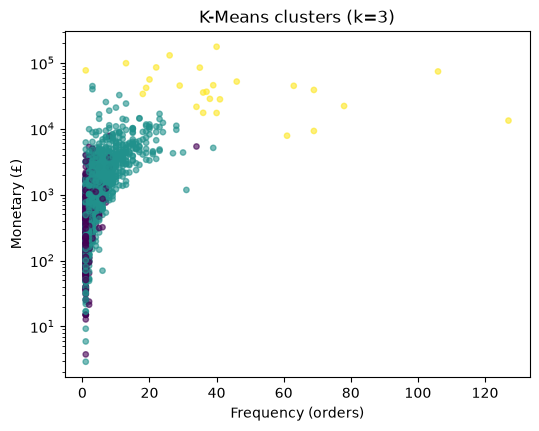

In [9]:
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_scaled)
sizes = pd.Series(kmeans.labels_).value_counts().sort_index()
print("Customers per cluster:")
print(sizes)
plt.figure(figsize=(6, 4.5))
plt.scatter(X["frequency"], X["monetary"], c=kmeans.labels_, cmap="viridis", s=15, alpha=0.6)
plt.xlabel("Frequency (orders)"); plt.ylabel("Monetary (£)"); plt.title("K-Means clusters (k=3)")
plt.yscale("log"); plt.show()